# CVE Risk Classification — 01: Data Preparation
**Imperial Business School Capstone | MSc Cybersecurity + AI/ML**

**Sources:** Kaggle — `francescomanzoni/vulnerability-management-datasets`  
**Files used:** `cve_cisa_epss_enriched_dataset.csv`, `cve_corpus.csv`

**Purpose:** Load, merge, clean and validate both datasets. Produce a single
analysis-ready DataFrame `df_clean` and save it to `data/df_clean.csv` for
use by all downstream notebooks.

> ⚠️ **Data cutoff note:** Dataset downloaded from Kaggle on *[INSERT DATE]*.
> NVD enrichment policy changed April 15 2026 (NIST triage model). CVEs
> published after that date may lack CVSS/CWE enrichment. See Section 3 of
> the capstone methodology for discussion.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, warnings
warnings.filterwarnings('ignore')

# ── Output directory ──────────────────────────────────────────────────────────
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Raw Files

In [ ]:
# ── Adjust paths to your local Kaggle download location ──────────────────────
METRICS_PATH = '/content/drive/Mydrive/cve_cisa_epss_enriched_dataset.csv'
CORPUS_PATH  = '/content/drive/Mydrive/cve_corpus.csv'

df_metrics = pd.read_csv(METRICS_PATH)
df_corpus  = pd.read_csv(CORPUS_PATH)

print(f'Metrics shape : {df_metrics.shape}')
print(f'Corpus shape  : {df_corpus.shape}')
print(f'Metrics cols  : {df_metrics.columns.tolist()}')
print(f'Corpus cols   : {df_corpus.columns.tolist()}')

Metrics shape : (155852, 17)
Corpus shape  : (211208, 4)
Metrics cols  : ['cve_id', 'base_severity', 'base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc', 'cisa_kev', 'attack_vector', 'attack_complexity', 'privileges_required', 'user_interaction', 'scope', 'confidentiality_impact', 'integrity_impact', 'availability_impact', 'published_date']
Corpus cols   : ['cve_id', 'description_data', 'cwe_data', 'cpe_data']


## 2. Merge on cve_id

In [ ]:
df = pd.merge(df_metrics, df_corpus, on='cve_id', how='inner')
print(f'Merged shape  : {df.shape}')
print(f'Merge loss    : {len(df_metrics) - len(df)} rows (metrics not in corpus)')
df.head(3)

Merged shape  : (155852, 20)
Merge loss    : 0 rows (metrics not in corpus)


,cve_id,base_severity,base_score,exploitability_score,impact_score,epss_score,epss_perc,cisa_kev,attack_vector,attack_complexity,privileges_required,user_interaction,scope,confidentiality_impact,integrity_impact,availability_impact,published_date,description_data,cwe_data,cpe_data
0,CVE-1999-0199,CRITICAL,9.8,3.9,5.9,0.00677,0.70539,False,NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,2020-10-06T13:15Z,"[""manual/search.texi in the GNU C Library (aka...",['CWE-252'],['cpe:2.3:a:gnu:glibc:*:*:*:*:*:*:*:*']
1,CVE-2002-20001,HIGH,7.5,3.9,3.6,0.11632,0.93382,False,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,2021-11-11T19:15Z,['The Diffie-Hellman Key Agreement Protocol al...,['CWE-400'],"['cpe:2.3:a:balasys:dheater:-:*:*:*:*:*:*:*', ..."
2,CVE-2002-2438,HIGH,7.5,3.9,3.6,0.04663,0.88880,False,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,2021-05-18T12:15Z,['TCP firewalls could be circumvented by sendi...,['CWE-287'],['cpe:2.3:o:linux:linux_kernel:*:*:*:*:*:*:*:*']


## 3. Target Variable Audit — base_severity

Class distribution (raw):
base_severity
MEDIUM      67272
HIGH        61680
CRITICAL    24153
LOW          2747
Name: count, dtype: int64

Missing base_severity: 0

Clean shape after label filter: (155852, 20)


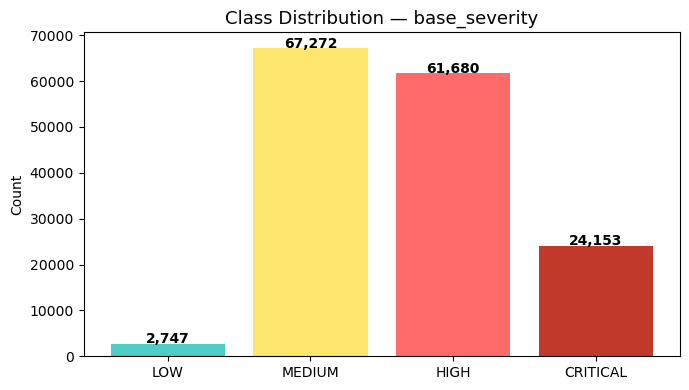

⚠️  Note imbalance — handled in notebook 03 with class_weight=balanced


In [ ]:
print('Class distribution (raw):')
print(df['base_severity'].value_counts())
print()
print('Missing base_severity:', df['base_severity'].isna().sum())

# ── Drop rows with no severity label (unclassifiable for supervised learning)
df = df.dropna(subset=['base_severity'])

# ── Normalise labels to uppercase (dataset sometimes has mixed case)
df['base_severity'] = df['base_severity'].str.upper().str.strip()
valid_labels = {'LOW', 'MEDIUM', 'HIGH', 'CRITICAL'}
df = df[df['base_severity'].isin(valid_labels)]

print(f'\nClean shape after label filter: {df.shape}')

# ── Class imbalance visualisation
fig, ax = plt.subplots(figsize=(7, 4))
order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
counts = df['base_severity'].value_counts().reindex(order)
bars = ax.bar(order, counts, color=['#4ECDC4','#FFE66D','#FF6B6B','#C0392B'])
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Class Distribution — base_severity', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150)
plt.show()
print('⚠️  Note imbalance — handled in notebook 03 with class_weight=balanced')

## 4. Missing Value Analysis

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_report)

# ── Strategy: numerical → median impute; categorical → 'UNKNOWN'
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna('UNKNOWN')

print(f'\nMissing values after imputation: {df.isnull().sum().sum()}')

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Missing values after imputation: 0


## 5. Feature Engineering — CVE Year & Era Taxonomy

In [ ]:
# ── Extract year from CVE-YYYY-NNNNN format
df['cve_year'] = df['cve_id'].str.split('-').str[1].astype(int, errors='ignore')

# ── Era taxonomy (original contribution — links to KEV ratios analysis)
def classify_era(year):
    if year < 2010:  return 'Antique'
    elif year < 2018: return 'Classic'
    else:            return 'Current'

df['cve_era'] = df['cve_year'].apply(classify_era)

print('Era distribution:')
print(df['cve_era'].value_counts())

# ── KEV ratio per era (validates era taxonomy)
if 'kev_flag' in df.columns or 'in_kev' in df.columns:
    kev_col = 'kev_flag' if 'kev_flag' in df.columns else 'in_kev'
    kev_ratio = df.groupby('cve_era')[kev_col].mean().sort_values(ascending=False)
    print('\nKEV ratio per era (higher = more exploited):')
    print(kev_ratio)

Era distribution:
cve_era
Current    147940
Classic      7802
Antique       110
Name: count, dtype: int64


## 6. Save Clean Dataset

In [ ]:
df.to_csv('data/df_clean.csv', index=False)
print(f'✓ df_clean.csv saved — shape: {df.shape}')
print(f'  Columns: {df.columns.tolist()}')

✓ df_clean.csv saved — shape: (155852, 22)
  Columns: ['cve_id', 'base_severity', 'base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc', 'cisa_kev', 'attack_vector', 'attack_complexity', 'privileges_required', 'user_interaction', 'scope', 'confidentiality_impact', 'integrity_impact', 'availability_impact', 'published_date', 'description_data', 'cwe_data', 'cpe_data', 'cve_year', 'cve_era']
